In [83]:
%pip install seaborn 

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [85]:
df = pd.read_csv("heart.csv")

In [86]:
df_clean=df.copy()
print(df_clean.head())

              name  Age   Sex   cp  RestingBP  chol  fbs RestingECG  MaxHR  \
0      Mary Miller   40     m  ATA      140.0   289    0     Normal  172.0   
1   Michael Garcia   49     f  NAP      160.0   180    0     Normal  156.0   
2  Thomas Gonzalez   37  Male  ATA      130.0   283    0         ST   98.0   
3     Karen Garcia   48     f  ASY      138.0   214    0     Normal  108.0   
4     Thomas Smith   54     m  NAP      150.0   195    0     Normal  122.0   

  exang  Oldpeak ST_Slope  HeartDisease  
0     N      0.0       Up             0  
1     N      1.0     Flat             1  
2     N      0.0       Up             0  
3     Y      1.5     Flat             1  
4     N      0.0       Up             0  


In [87]:
df_clean.drop('name', axis=1, inplace=True, errors='ignore')
print("--- null values count ---\n")
print(df_clean.isnull().sum())

--- null values count ---

Age             0
Sex             1
cp              0
RestingBP       1
chol            0
fbs             0
RestingECG      3
MaxHR           1
exang           0
Oldpeak         2
ST_Slope        1
HeartDisease    0
dtype: int64


In [88]:
df_clean['Sex'] = df_clean['Sex'].replace({
    'Male':1,'Female':0,'M':1,'F':0,
    'female':0,'male':1,'f':0,'m':1
})
df_clean['Sex'] = df_clean['Sex'].fillna(df_clean['Sex'].mode()[0])
print(df_clean['Sex'].head())

<ipython-input-88-e67a299e660b>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['Sex'] = df_clean['Sex'].replace({


0    1.0
1    0.0
2    1.0
3    0.0
4    1.0
Name: Sex, dtype: float64


In [89]:
df_clean['exang'] = df_clean['exang'].map({'N': 0, 'Y': 1})
df_clean['exang'] = df_clean['exang'].fillna(df_clean['exang'].mode()[0])
print(df_clean['exang'].head())

0    0
1    0
2    0
3    1
4    0
Name: exang, dtype: int64


In [90]:
df_clean['chol'] = df_clean['chol'].replace(0, np.nan)
df_clean['chol'] = df_clean['chol'].fillna(df_clean['chol'].median())
print(df_clean['chol'].head())

0    289.0
1    180.0
2    283.0
3    214.0
4    195.0
Name: chol, dtype: float64


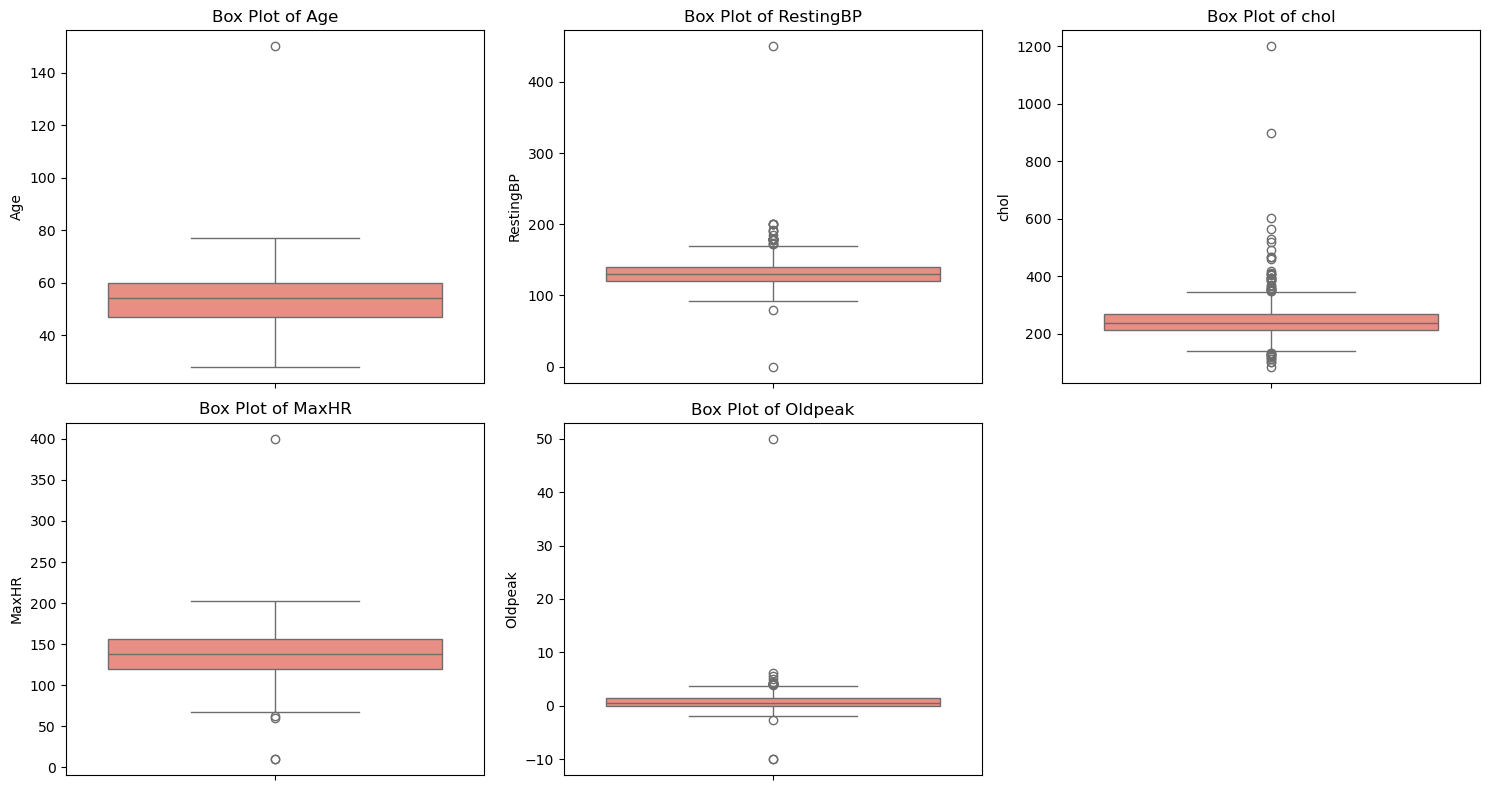

In [91]:
num_cols = ['Age', 'RestingBP', 'chol', 'MaxHR', 'Oldpeak']
plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_clean[col], color='salmon')
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

In [92]:
constraints = {
    'Age': [0, 120],          
    'RestingBP': [50, 300],    
    'chol': [50, 400],         
    'MaxHR': [50, 220],       
    'Oldpeak': [0,6]       
}
print(f"Original shape: {df_clean.shape}")

for col, bounds in constraints.items():
    if col in df_clean.columns:
        initial_count = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= bounds[0]) & (df_clean[col] <= bounds[1])]
        dropped = initial_count - len(df_clean)
        if dropped > 0:
            print(f"Removed {dropped} rows from '{col}' exceeding range {bounds}")

print(f"\nFinal cleaned shape: {df_clean.shape}")

Original shape: (918, 12)
Removed 1 rows from 'Age' exceeding range [0, 120]
Removed 3 rows from 'RestingBP' exceeding range [50, 300]
Removed 15 rows from 'chol' exceeding range [50, 400]
Removed 4 rows from 'MaxHR' exceeding range [50, 220]
Removed 19 rows from 'Oldpeak' exceeding range [0, 6]

Final cleaned shape: (876, 12)


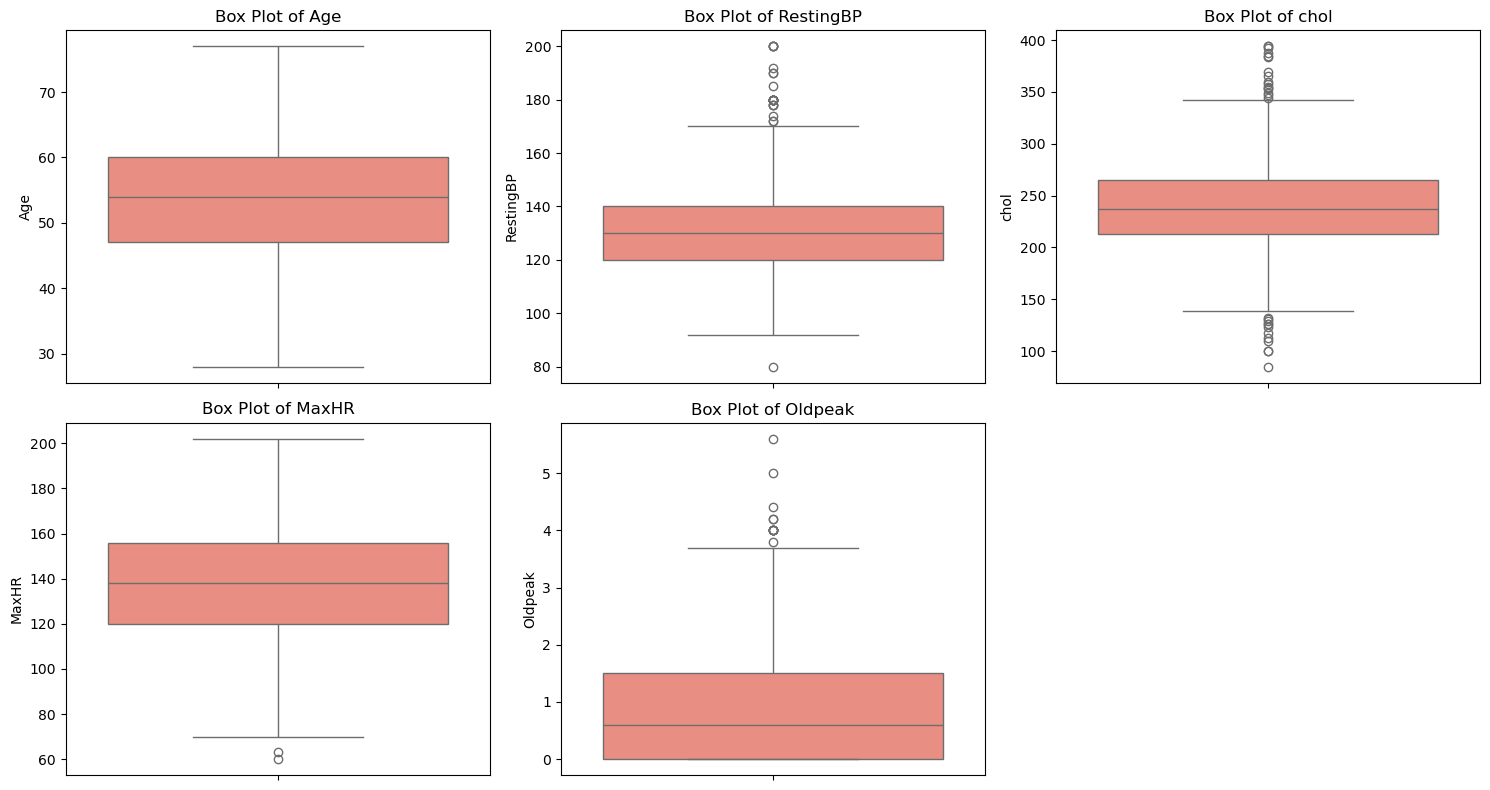

In [93]:
num_cols = ['Age', 'RestingBP', 'chol', 'MaxHR', 'Oldpeak']
plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_clean[col], color='salmon')
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

In [94]:
df_clean['RestingBP'] = df_clean['RestingBP'].replace(0, np.nan)
cols_to_median = ['Oldpeak', 'RestingBP']
df_clean[cols_to_median] = df_clean[cols_to_median].fillna(df_clean[cols_to_median].median())
cols_to_mode = ['Sex', 'RestingECG', 'ST_Slope', 'HeartDisease']
for col in cols_to_mode:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
df_clean['MaxHR'] = df_clean['MaxHR'].fillna(df_clean['MaxHR'].mean())
df_clean.fillna(df_clean.median(numeric_only=True), inplace=True)

print(df_clean.isnull().sum())

Age             0
Sex             0
cp              0
RestingBP       0
chol            0
fbs             0
RestingECG      0
MaxHR           0
exang           0
Oldpeak         0
ST_Slope        0
HeartDisease    0
dtype: int64


In [95]:
categorical_cols = ['cp', 'RestingECG', 'ST_Slope']
for col in categorical_cols:
    if col in df_clean.columns:
        mode = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode)
        encoded = pd.get_dummies(df_clean[col], prefix=col, drop_first=True).astype(int)
        df_clean = pd.concat([df_clean, encoded], axis=1)
        df_clean.drop(col, axis=1, inplace=True)
print(df_clean.columns.tolist())
print("\n")
print(df_clean.head())

['Age', 'Sex', 'RestingBP', 'chol', 'fbs', 'MaxHR', 'exang', 'Oldpeak', 'HeartDisease', 'cp_ATA', 'cp_NAP', 'cp_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']


   Age  Sex  RestingBP   chol  fbs  MaxHR  exang  Oldpeak  HeartDisease  \
0   40  1.0      140.0  289.0    0  172.0      0      0.0             0   
1   49  0.0      160.0  180.0    0  156.0      0      1.0             1   
2   37  1.0      130.0  283.0    0   98.0      0      0.0             0   
3   48  0.0      138.0  214.0    0  108.0      1      1.5             1   
4   54  1.0      150.0  195.0    0  122.0      0      0.0             0   

   cp_ATA  cp_NAP  cp_TA  RestingECG_Normal  RestingECG_ST  ST_Slope_Flat  \
0       1       0      0                  1              0              0   
1       0       1      0                  1              0              1   
2       1       0      0                  0              1              0   
3       0       0      0                  1         


--- Features Correlated with Heart Disease ---

HeartDisease         1.000000
ST_Slope_Flat        0.554970
exang                0.501349
Oldpeak              0.433338
Sex                  0.315578
Age                  0.289115
fbs                  0.268817
RestingBP            0.117943
RestingECG_ST        0.102419
chol                 0.071163
cp_TA               -0.059331
RestingECG_Normal   -0.094900
cp_NAP              -0.205118
MaxHR               -0.402638
cp_ATA              -0.403515
ST_Slope_Up         -0.621051
Name: HeartDisease, dtype: float64


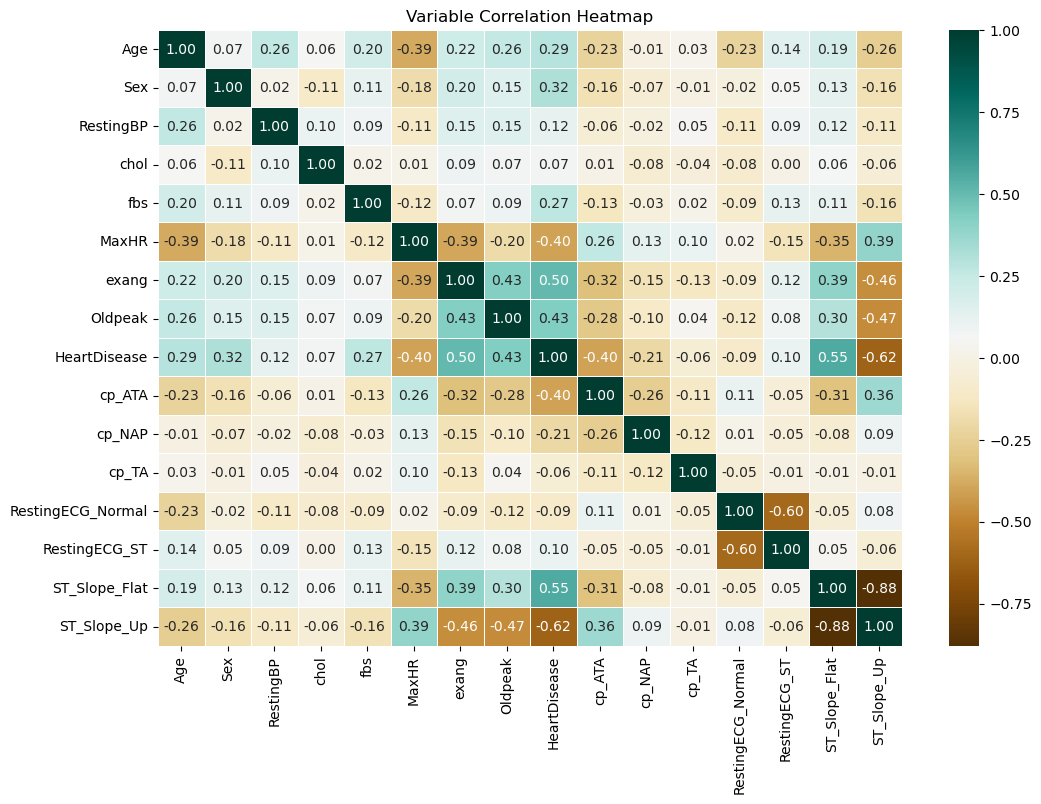


--- Selected Important Features ---

HeartDisease     1.000000
ST_Slope_Flat    0.554970
exang            0.501349
Oldpeak          0.433338
Sex              0.315578
Age              0.289115
fbs              0.268817
RestingBP        0.117943
RestingECG_ST    0.102419
cp_NAP          -0.205118
MaxHR           -0.402638
cp_ATA          -0.403515
ST_Slope_Up     -0.621051
Name: HeartDisease, dtype: float64


In [96]:
correlation_matrix = df_clean.corr(numeric_only=True)
target_corr = correlation_matrix['HeartDisease'].sort_values(ascending=False)
print("\n--- Features Correlated with Heart Disease ---\n")
print(target_corr)

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='BrBG', fmt=".2f", linewidths=0.5)
plt.title("Variable Correlation Heatmap")
plt.show()

important_features = target_corr[abs(target_corr) >= 0.1].sort_values(ascending=False)
print("\n--- Selected Important Features ---\n")
print(important_features)

In [97]:
features = important_features.index.drop('HeartDisease')
X = df_clean[features]
y = df_clean['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
num_cols = ['Oldpeak', 'MaxHR', 'RestingBP', 'Age', 'chol']

scale_these = X.columns.intersection(num_cols)

X_train[scale_these] = scaler.fit_transform(X_train[scale_these])
X_test[scale_these] = scaler.transform(X_test[scale_these])

print("Data Scaled Successfully\n")
print(X_train[scale_these].head())

Data Scaled Successfully

      Oldpeak       Age  RestingBP     MaxHR
423  0.553244  0.655411   2.666237  0.127417
574  0.553244  1.619026   0.503192 -0.982035
551 -0.869151  0.869548  -0.749096 -2.012240
806  1.596333  1.726095   0.673959 -0.466932
245  1.027375  0.013001  -0.749096  0.008547
